In [1]:
# Imports
import polars as pl
pl.Config.set_fmt_str_lengths(100)
import numpy as np
import seaborn as sns
import pandas as pd
from joblib import Parallel, delayed

import matplotlib.pylab as plt
from conversions import get_file_without_path
import glob
import os
import pickle

from sklearn.feature_selection import mutual_info_regression
from scipy import signal
from scipy import stats
import random
from scipy.stats import spearmanr
import pingouin

import pandas as pd
import numpy as np
import mne
from mne.stats import permutation_cluster_test
import matplotlib.pyplot as plt


/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


# Synchrony

# Synchrony analysis for each analysis type

In [2]:
# Initialize the dataframes with the correct schema if they are not initialized
df_lags_schema = {
    "lag": pl.Int64,
    "corr": pl.Float64,
    "dyad": pl.Utf8,
    "source_feature": pl.Utf8,
    "target_feature": pl.Utf8,
    "participant_manipulated": pl.Boolean,
    "other_manipulated": pl.Boolean,
    "other_id": pl.Utf8,
    "sid": pl.Utf8,
    "user_id": pl.Utf8,
    "window": pl.Int64,
    "start": pl.Int64,
    "start_time": pl.Int64,
    "real_dyad": pl.Boolean,
    "repetition_nb": pl.Int64,
    "analysis" : pl.Utf8
}

mi_df_schema = {
    "source_feature": pl.Utf8,
    "target_feature": pl.Utf8,
    "other_id": pl.Utf8,
    "user_id": pl.Utf8,
    "participant_manipulated": pl.Boolean,
    "other_manipulated": pl.Boolean,
    "dyad": pl.Utf8,
    "sid": pl.Utf8,
    "mi": pl.Float64,
    "max_corr": pl.Float64,
    "mean_corr": pl.Float64,
    "window": pl.Int64,
    "start": pl.Int64,
    "start_time": pl.Int64,
    "real_dyad": pl.Boolean,
    "repetition_nb": pl.Int64,
    "analysis" : pl.Utf8
}

## MI

In [49]:
#Read csvs in parallel processes
def process_file(file):
    df = pl.read_csv(file, schema_overrides=schema)
    df = df.with_columns([pl.col(column).cast(dtype) for column, dtype in schema.items()])
    #df = df.filter(pl.col("repetition_nb") == 0) #for efficiency and memory handling

    return df

# Read and process CSV files in parallel
schema = mi_df_schema
csv_files = glob.glob("data/synchrony_for_each_ppg_method_repetition_1_lag_30_overlap_5/*mi_df.csv")
dfs = Parallel(n_jobs=-1)(delayed(process_file)(file) for file in csv_files)

# Concatenate all dataframes
all_data_df = pl.concat(dfs, how="vertical")

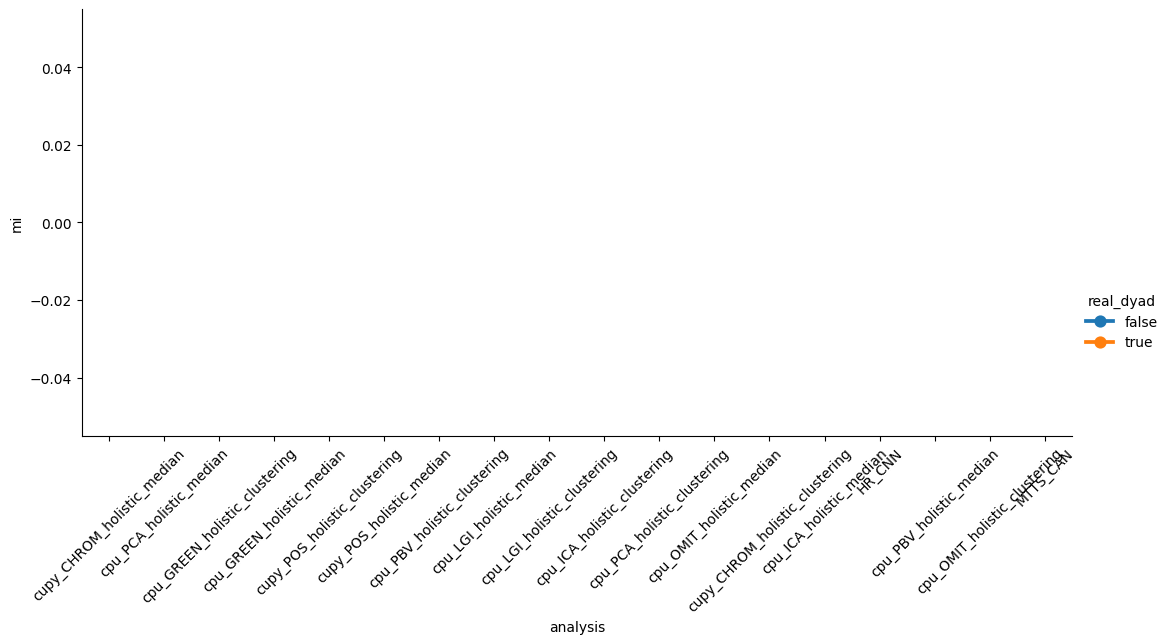

In [73]:
df_analysis = all_data_df.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "repetition_nb", "analysis"]).mean().to_pandas(
)
#df_analysis = df_analysis.loc[df_analysis["mi"]<0.2]

sns.catplot(x="analysis", y="mi", hue="real_dyad"
                  , data=df_analysis
                  , aspect=2.2
                  , height=5
                  , kind="point"
                  , capsize=0.15
                  , hue_order=[False, True]
           )

x = plt.xticks(rotation=45);  # Rotate x-axis labels by 45 degrees

In [ ]:
df_analysis = all_data_df.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "repetition_nb", "analysis"]).mean().to_pandas(
)
#df_analysis = df_analysis.loc[df_analysis["mi"]<0.2]

sns.catplot(x="analysis", y="mean_corr", hue="real_dyad"
                  , data=df_analysis
                  , aspect=2.2
                  , height=5
                  , kind="point"
                  , capsize=0.15
                  , hue_order=[False, True]
           )

x = plt.xticks(rotation=45);  # Rotate x-axis labels by 45 degrees


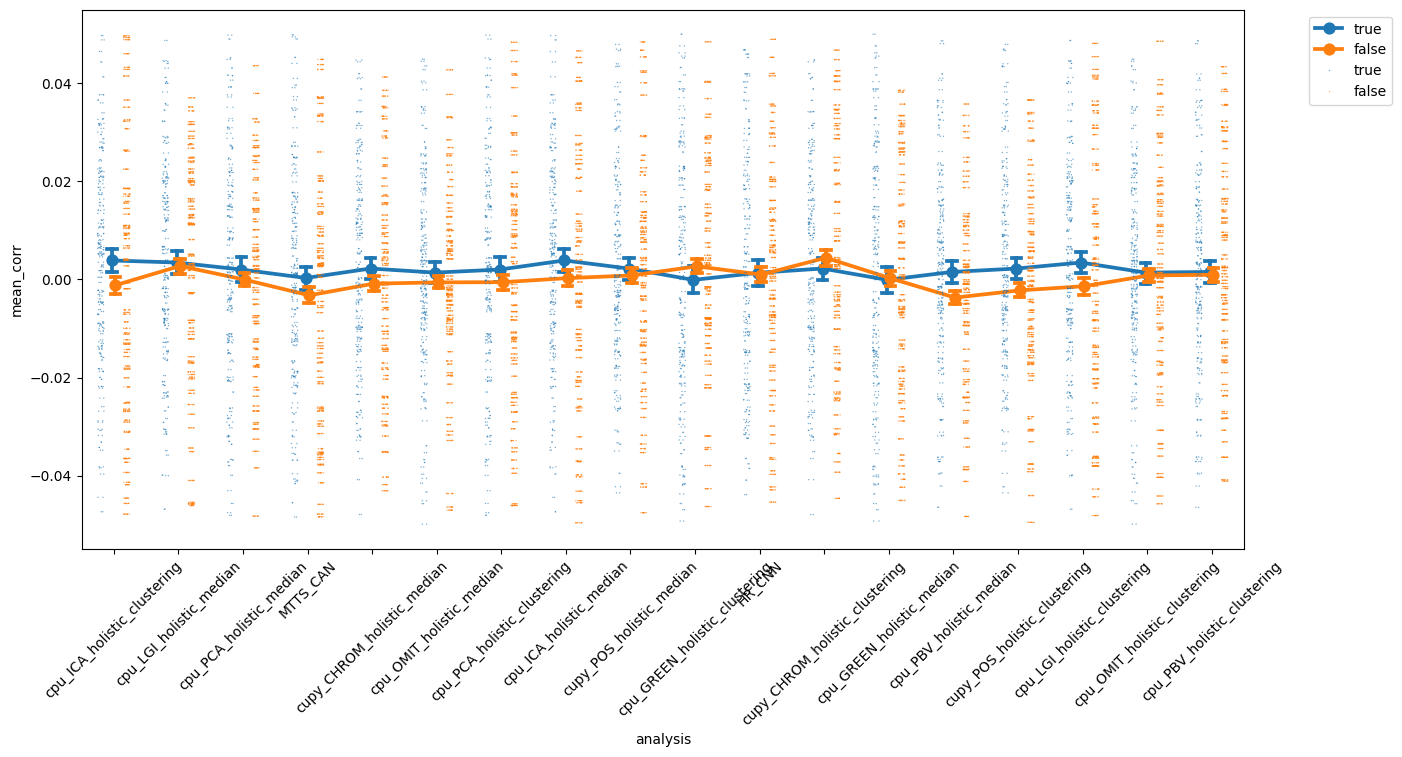

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_analysis is already defined
df_analysis = all_data_df.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "repetition_nb", "analysis"]).mean().to_pandas()

df_analysis = df_analysis.loc[df_analysis["mean_corr"] < 0.05]
df_analysis = df_analysis.loc[df_analysis["mean_corr"] > -0.05]

# Create a figure and a single axis
plt.figure(figsize=(15, 7))

# Plot the point plot with error bars
sns.pointplot(
    x="analysis", 
    y="mean_corr", 
    hue="real_dyad", 
    data=df_analysis, 
    capsize=0.15, 
    dodge=True, 
    markers='o', 
    linestyles='-', 
)

# Plot the strip plot with transparency
sns.stripplot(
    x="analysis", 
    y="mean_corr", 
    hue="real_dyad", 
    data=df_analysis, 
    dodge=True, 
    alpha=0.6, 
    jitter=True,
    size=1,
    legend=False
)

# Rotate x-axis labels by 45 degrees for better readability
plt.xticks(rotation=45)

# Adjust legend to prevent overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()


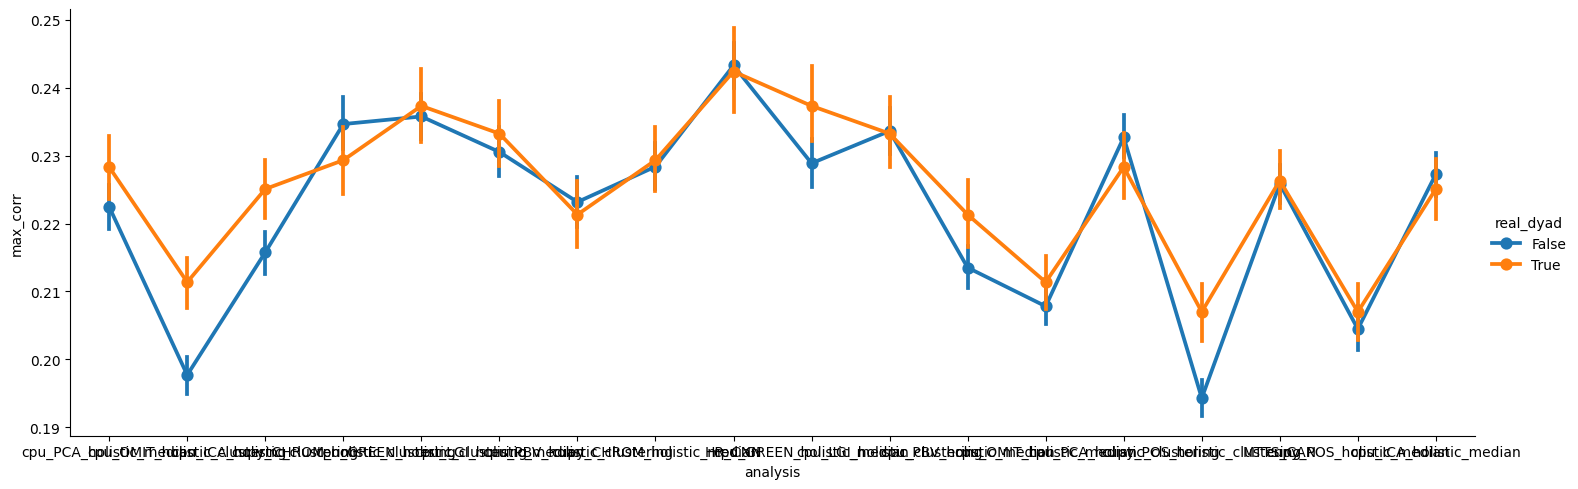

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_analysis is already defined
df_analysis = all_data_df.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "repetition_nb"]).mean().to_pandas()

df_analysis = df_analysis.loc[df_analysis["mean_corr"] < 0.05]
df_analysis = df_analysis.loc[df_analysis["mean_corr"] > -0.05]

# Create a figure and a single axis
plt.figure(figsize=(15, 7))

# Plot the point plot with error bars
sns.pointplot(
    x="analysis", 
    y="max_corr", 
    hue="real_dyad", 
    data=df_analysis, 
    capsize=0.15, 
    dodge=True, 
    markers='o', 
    linestyles='-', 
)

# Plot the strip plot with transparency
sns.stripplot(
    x="analysis", 
    y="max_corr", 
    hue="real_dyad", 
    data=df_analysis, 
    dodge=True, 
    alpha=0.6, 
    jitter=True,
    size=1,
    legend=False
)

# Rotate x-axis labels by 45 degrees for better readability
plt.xticks(rotation=45)

# Adjust legend to prevent overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_analysis is already defined
df_analysis = all_data_df.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "repetition_nb"]).mean().to_pandas()

df_analysis = df_analysis.loc[df_analysis["mean_corr"] < 0.05]
df_analysis = df_analysis.loc[df_analysis["mean_corr"] > -0.05]

# Create a figure and a single axis
plt.figure(figsize=(15, 7))

# Plot the point plot with error bars
sns.pointplot(
    x="analysis", 
    y="max_corr", 
    hue="real_dyad", 
    data=df_analysis, 
    capsize=0.15, 
    dodge=True, 
    markers='o', 
    linestyles='-', 
)

# Plot the strip plot with transparency
sns.stripplot(
    x="analysis", 
    y="max_corr", 
    hue="real_dyad", 
    data=df_analysis, 
    dodge=True, 
    alpha=0.6, 
    jitter=True,
    size=1,
    legend=False
)

# Rotate x-axis labels by 45 degrees for better readability
plt.xticks(rotation=45)

# Adjust legend to prevent overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()


In [ ]:
behavior_df = pl.read_csv("data/behavior/all_data_df.csv")
behavior_df = behavior_df.with_columns(
    pl.col("sid").str.replace_all(":", "").alias("sid"),
    pl.col("user_id").str.replace_all(":", "").alias("user_id"),
    pl.col("other_id").str.replace_all(":", "").alias("other_id")
)

## CORR

In [3]:
#Read csvs in parallel processes
def process_file(file):
    df = pl.read_csv(file, schema_overrides=schema)
    df = df.with_columns([pl.col(column).cast(dtype) for column, dtype in schema.items()])
    #df = df.filter(pl.col("repetition_nb") == 1) #for efficiency and memory handling
    return df

# Read and process CSV files in parallel
schema = df_lags_schema
#csv_files = glob.glob("data/synchrony_for_each_ppg_method_repetition_1_lag_30_overlap_5/*df_lags.csv")
csv_files = glob.glob("data/synchrony_for_each_ppg_method_repetition_2_lag_20_overlap_1_wl_100/*df_lags.csv")

# --> csv_files = glob.glob("synchrony_for_each_ppg_method_repetition_2_lag_15_overlap_1_wl_30)

dfs = Parallel(n_jobs=-1)(delayed(process_file)(file) for file in csv_files)

# Concatenate all dataframes
df_lags = pl.concat(dfs, how="vertical")
df_lags.head()

lag,corr,dyad,source_feature,target_feature,participant_manipulated,other_manipulated,other_id,sid,user_id,window,start,start_time,real_dyad,repetition_nb,analysis
i64,f64,str,str,str,bool,bool,str,str,str,i64,i64,i64,bool,i64,str
-20,-0.112838,"""p3p7""","""bpmES""","""bpmES""",false,false,"""mkreal_meeting_experiment_prolific5p7""","""mkreal_meeting_experiment_prolific5""","""mkreal_meeting_experiment_prolific5p3""",0,0,0,false,0,"""cpu_OMIT_holistic_median"""
-19,-0.010476,"""p3p7""","""bpmES""","""bpmES""",false,false,"""mkreal_meeting_experiment_prolific5p7""","""mkreal_meeting_experiment_prolific5""","""mkreal_meeting_experiment_prolific5p3""",0,0,0,false,0,"""cpu_OMIT_holistic_median"""
-18,0.032009,"""p3p7""","""bpmES""","""bpmES""",false,false,"""mkreal_meeting_experiment_prolific5p7""","""mkreal_meeting_experiment_prolific5""","""mkreal_meeting_experiment_prolific5p3""",0,0,0,false,0,"""cpu_OMIT_holistic_median"""
-17,0.073119,"""p3p7""","""bpmES""","""bpmES""",false,false,"""mkreal_meeting_experiment_prolific5p7""","""mkreal_meeting_experiment_prolific5""","""mkreal_meeting_experiment_prolific5p3""",0,0,0,false,0,"""cpu_OMIT_holistic_median"""
-16,0.03648,"""p3p7""","""bpmES""","""bpmES""",false,false,"""mkreal_meeting_experiment_prolific5p7""","""mkreal_meeting_experiment_prolific5""","""mkreal_meeting_experiment_prolific5p3""",0,0,0,false,0,"""cpu_OMIT_holistic_median"""


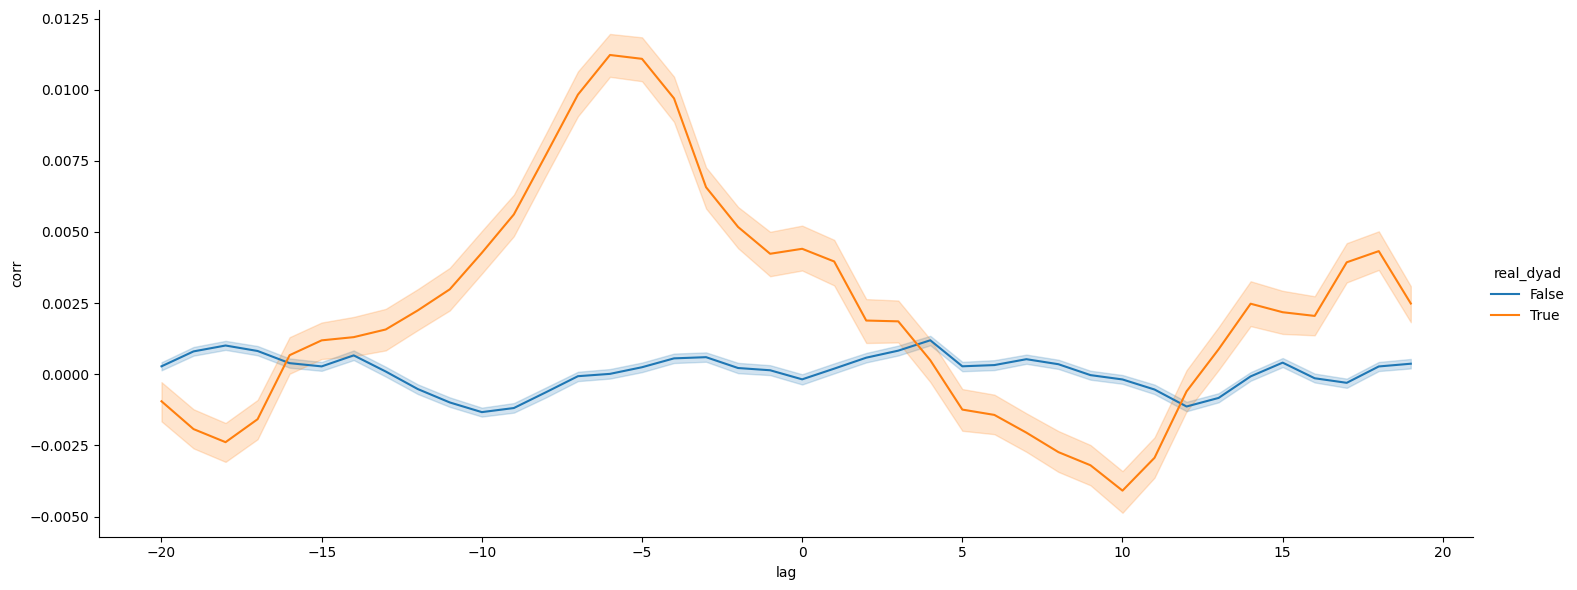

In [4]:
df_analysis = df_lags.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "window", "lag"]).mean().to_pandas()

sns.relplot(x="lag", y="corr",hue="real_dyad", data=df_analysis, aspect=2.5, height=6, kind="line")

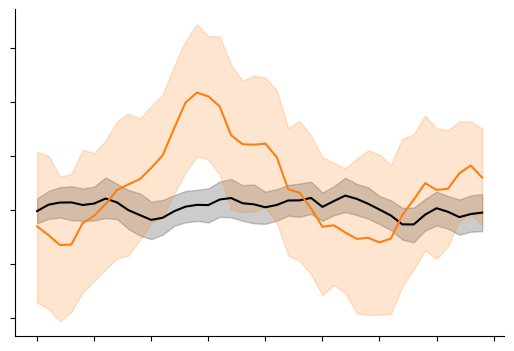

In [4]:
df_analysis = df_lags.group_by(["sid", "user_id", "real_dyad", "lag"]).mean().to_pandas()

g = sns.relplot(x="lag", y="corr", hue="real_dyad"
                , data=df_analysis, aspect=1.5, height=4, kind="line", errorbar=('ci', 95)
                , palette = ["#000000", "#FD7F11"]
                , legend=False
               )

plt.savefig("plots/hr_lags_legend.pdf", bbox_inches='tight')
g.set(xticklabels=[], yticklabels=[], title='',xlabel=None, ylabel=None)
plt.savefig("plots/hr_lags.pdf", bbox_inches='tight')


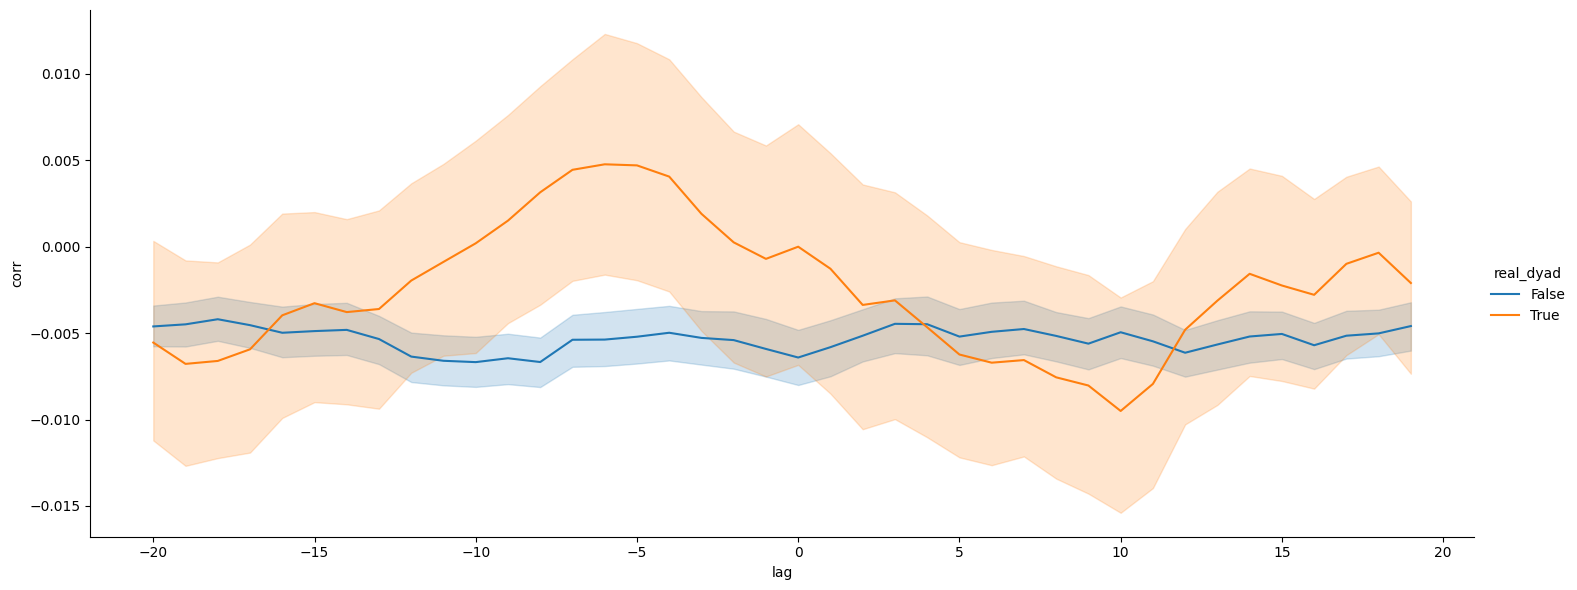

In [18]:
df_analysis = df_lags
df_analysis = df_analysis.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "lag"]).median().to_pandas()

sns.relplot(x="lag", y="corr", hue="real_dyad", data=df_analysis, aspect=2.5, height=6, kind="line")

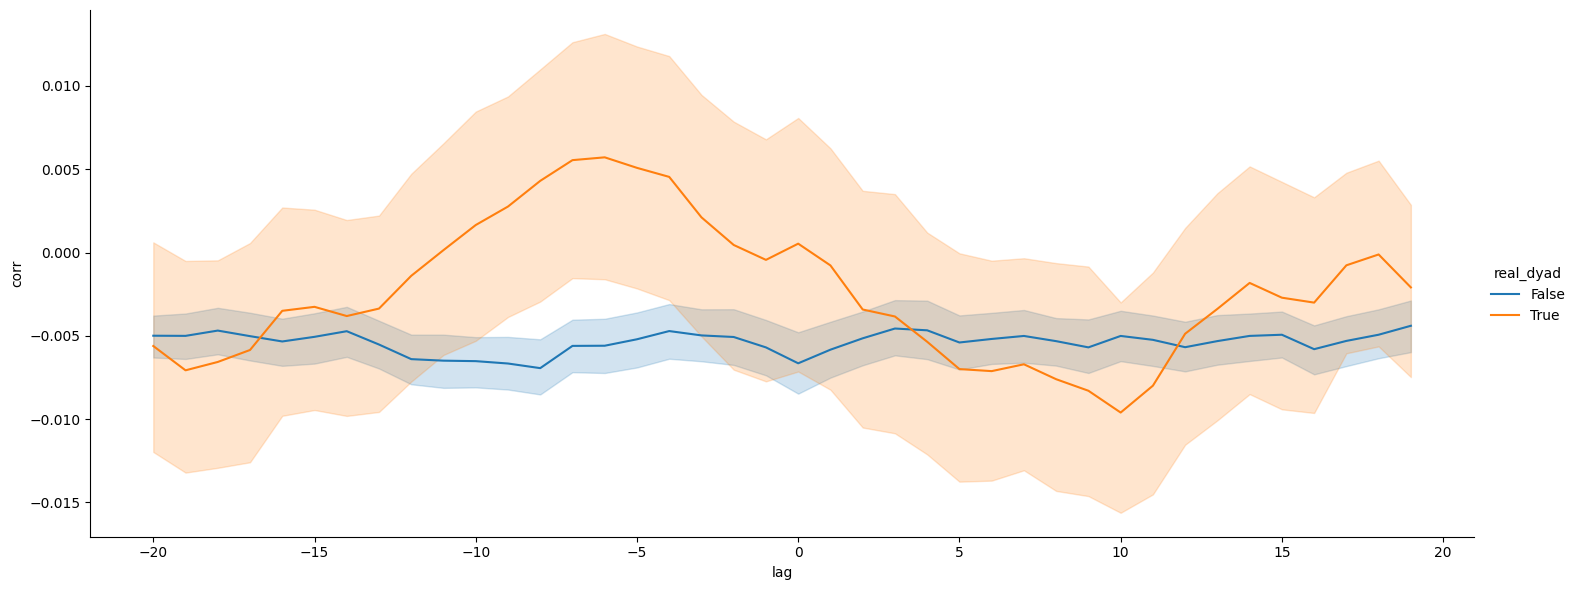

In [19]:
df_analysis = df_lags
df_analysis = df_analysis.filter(pl.col("analysis") != "MTTS_CAN")
df_analysis = df_analysis.filter(pl.col("analysis") != "HR_CNN")
df_analysis = df_analysis.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "lag"]).median().to_pandas()

sns.relplot(x="lag", y="corr", hue="real_dyad"
            , data=df_analysis, aspect=2.5, height=6, kind="line"
            , hue_order = [False, True]
            , palette= sns.color_palette(["red", "blue"])
           
           )

In [6]:
# Group and aggregate the data
df_analysis = df_lags
df_analysis = df_analysis.filter(pl.col("repetition_nb")==0)
df_analysis = df_analysis.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "lag"]).mean().to_pandas()

Shape of data_true: (58, 40)
Shape of data_false: (58, 40)
stat_fun(H1): min=0.001584855765904579 max=10.535736402362893
Running initial clustering …
Found 1 cluster


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Raw clusters:
Cluster 1: (array([11, 12, 13, 14, 15, 16]),)
Significant clusters (p <= 0.05):
Cluster 1:
Indices: [11 12 13 14 15 16]
Lag range: -9 to -4
p-value: 0.016


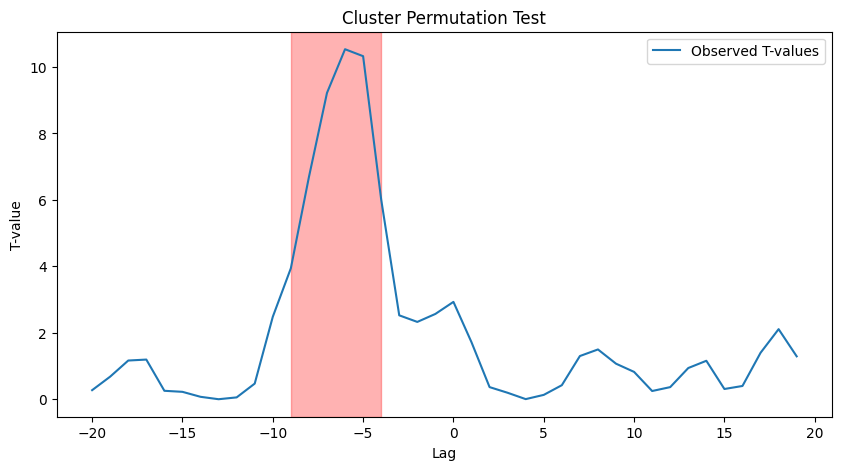

In [5]:
# Group and aggregate the data
df_analysis = df_lags
df_analysis = df_analysis.filter(pl.col("repetition_nb")==0)
df_analysis = df_analysis.group_by(["sid", "user_id", "real_dyad", "lag"]).mean().to_pandas()

# Pivot the data to have separate columns for True and False real_dyad
df_pivot = df_analysis.pivot_table(index=["sid", "user_id", "lag"], 
                                   columns="real_dyad", values="corr").reset_index()

# Rename the columns for clarity
df_pivot.columns = ['sid', 'user_id',  'lag', 'False', 'True']

# Prepare the data for mne
times = df_pivot['lag'].unique()

data_true = df_pivot[df_pivot['True'].notna()]['True'].values.reshape(-1, len(times))
data_false = df_pivot[df_pivot['False'].notna()]['False'].values.reshape(-1, len(times))

# Print shapes of the data arrays for debugging
print("Shape of data_true:", data_true.shape)
print("Shape of data_false:", data_false.shape)

# Print data samples for initial lags
#print("Data at initial lags for True condition:", data_true[:, 0])
#print("Data at initial lags for False condition:", data_false[:, 0])

# Ensure the data is correctly reshaped
assert data_true.shape[1] == len(times), "Reshaping error for True data"
assert data_false.shape[1] == len(times), "Reshaping error for False data"

# Combine the data for the test
data = [data_true, data_false]

# Perform the cluster permutation test
T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
    data, n_permutations=1000, threshold=3.842517, tail=1, n_jobs=1)

# Print the raw clusters
print("Raw clusters:")
for i, cluster in enumerate(clusters):
    print(f"Cluster {i+1}: {cluster}")

# Print the significant clusters with indices
print("Significant clusters (p <= 0.05):")
for i_c, c in enumerate(clusters):
    if cluster_p_values[i_c] <= 0.05:
        c_indices = c[0]  # Extract indices of the cluster
        print(f"Cluster {i_c + 1}:")
        print(f"Indices: {c_indices}")
        print(f"Lag range: {times[c_indices[0]]} to {times[c_indices[-1]]}")
        print(f"p-value: {cluster_p_values[i_c]}")

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(times, T_obs, label='Observed T-values')
plt.xlabel('Lag')
plt.ylabel('T-value')
plt.title('Cluster Permutation Test')

# Highlight significant clusters
for i_c, c in enumerate(clusters):
    if cluster_p_values[i_c] <= 0.05:
        c_indices = c[0]  # Extract indices of the cluster
        plt.axvspan(times[c_indices[0]], times[c_indices[-1]], color='r', alpha=0.3)

plt.legend()
plt.show()


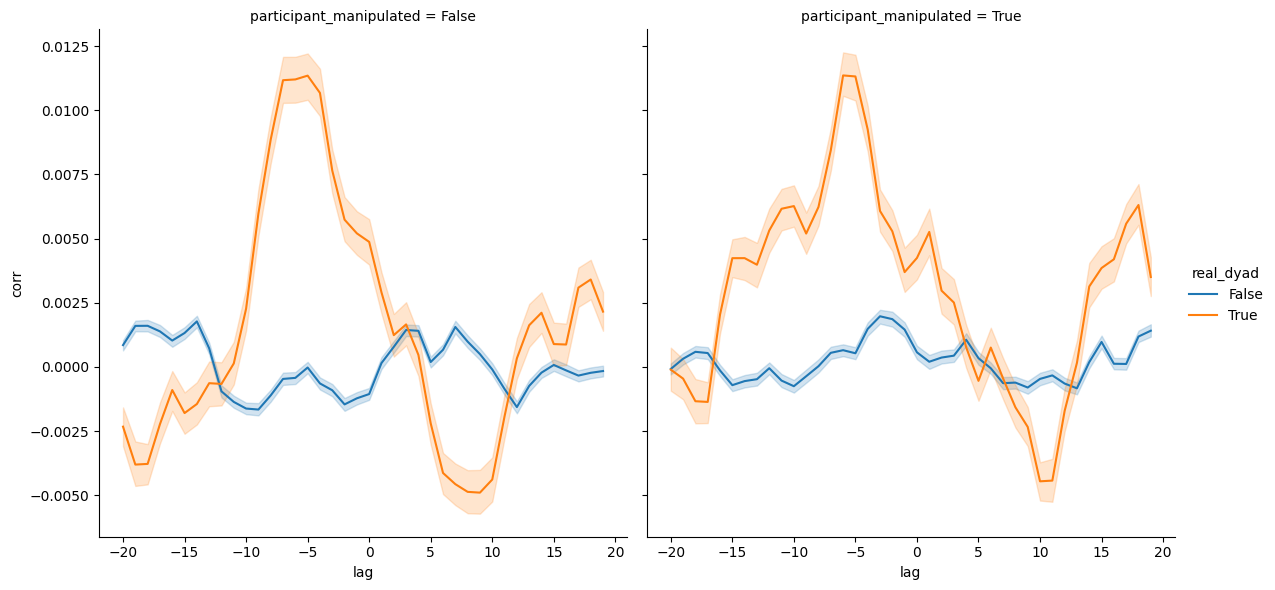

In [8]:
df_analysis = df_lags.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "window", "lag", "participant_manipulated"]).mean().to_pandas()

#df_analysis = df_analysis.loc[df_analysis["mi"]<0.15]

sns.relplot(x="lag", y="corr",hue="real_dyad", col="participant_manipulated", data=df_analysis, aspect=1, height=6, kind="line")

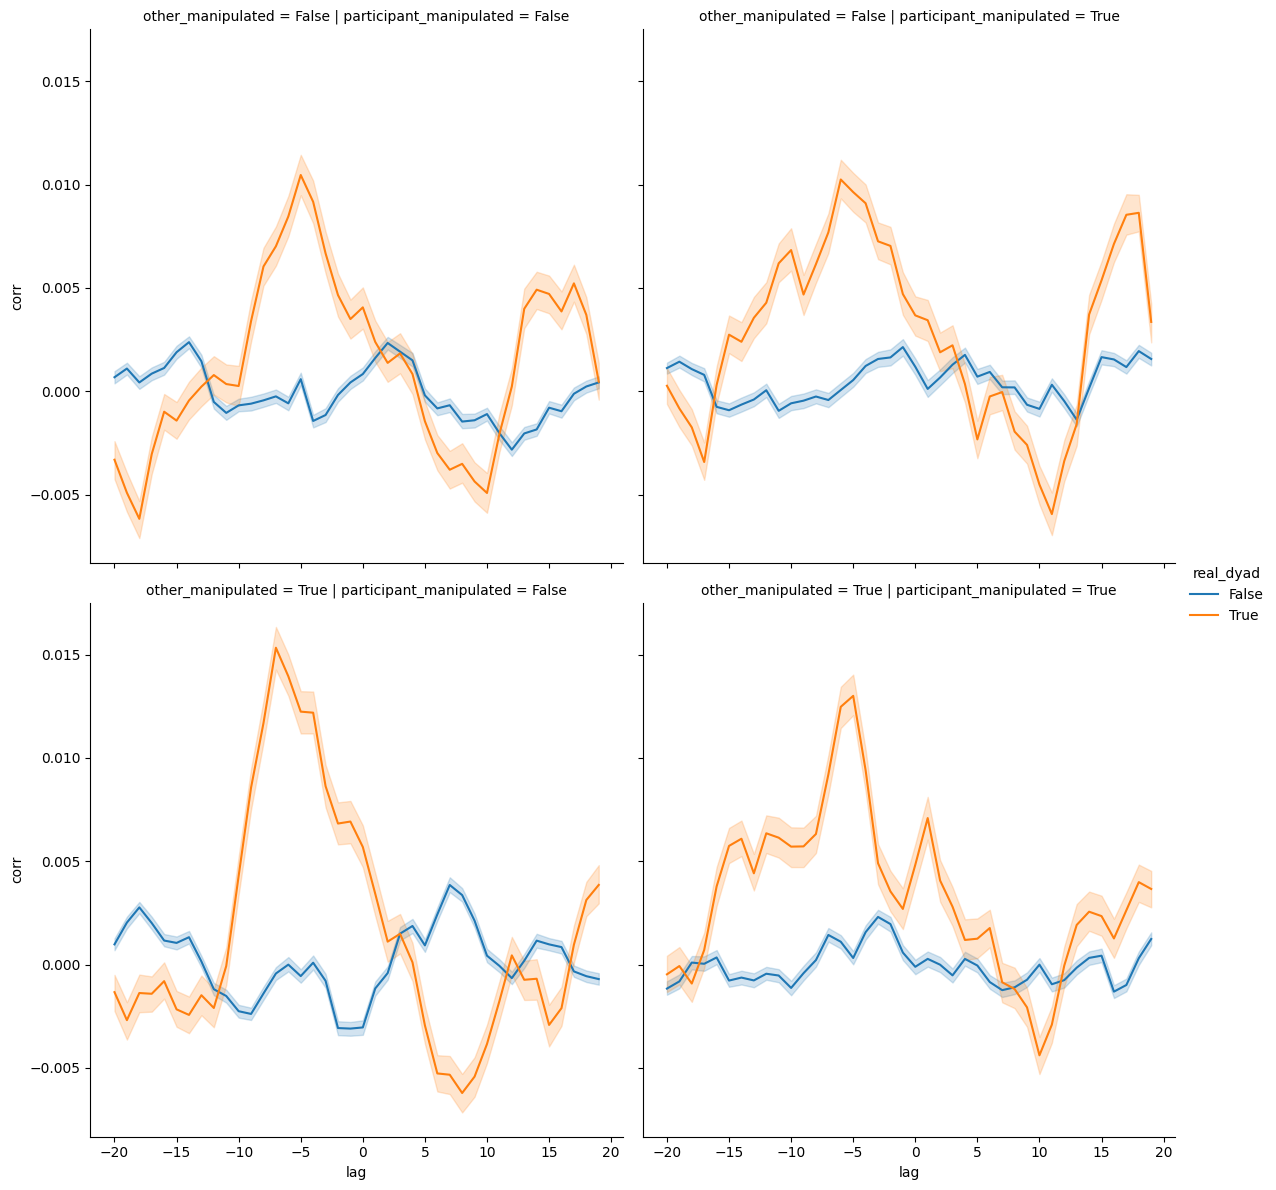

In [9]:
df_analysis = df_lags.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "window", "lag", "participant_manipulated", "other_manipulated"]).mean().to_pandas()

#df_analysis = df_analysis.loc[df_analysis["mi"]<0.15]

sns.relplot(x="lag", y="corr",hue="real_dyad", col="participant_manipulated", row="other_manipulated",data=df_analysis, aspect=1, height=6, kind="line")

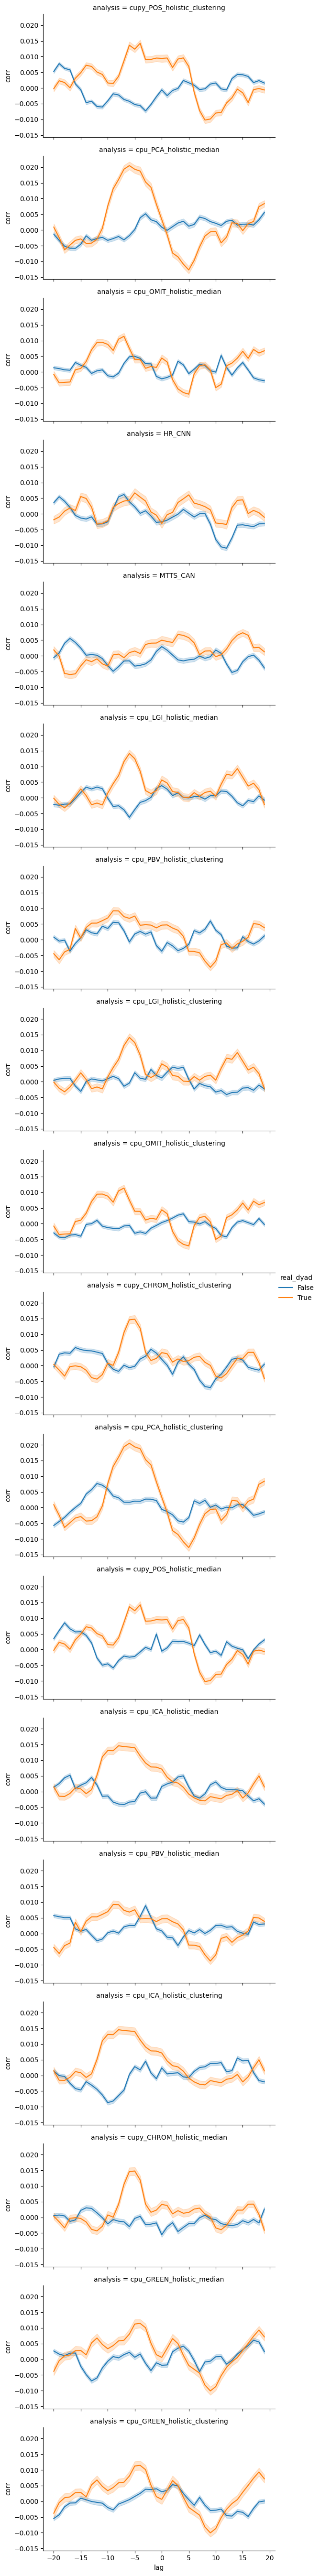

In [11]:
df_analysis = df_lags.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "window", "analysis", "lag"]).mean().to_pandas()

#df_analysis = df_analysis.loc[df_analysis["mi"]<0.15]

sns.relplot( x="lag", y="corr",hue="real_dyad", row="analysis", data=df_analysis, aspect=2, height=3, kind="line" )

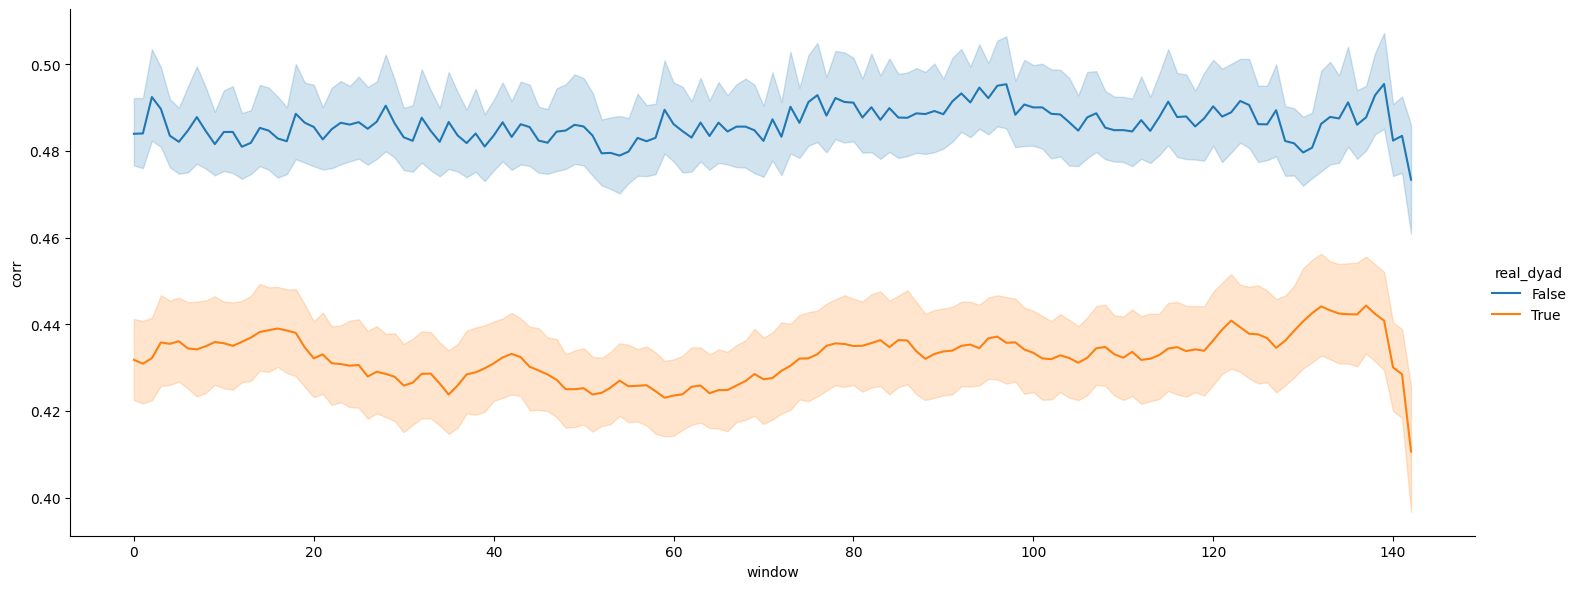

In [69]:
# Where in time is the effect?
df_analysis = df_lags
df_analysis = df_analysis.filter(pl.col(["lag"]) > -10)
df_analysis = df_analysis.filter(pl.col(["lag"]) < 10)

df_analysis = df_analysis.with_columns(pl.col("corr").abs().alias("corr"))

df_analysis = df_analysis.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "window"]).max().to_pandas()

sns.relplot(x="window", y="corr",hue="real_dyad", data=df_analysis, aspect=2.5, height=6, kind="line")

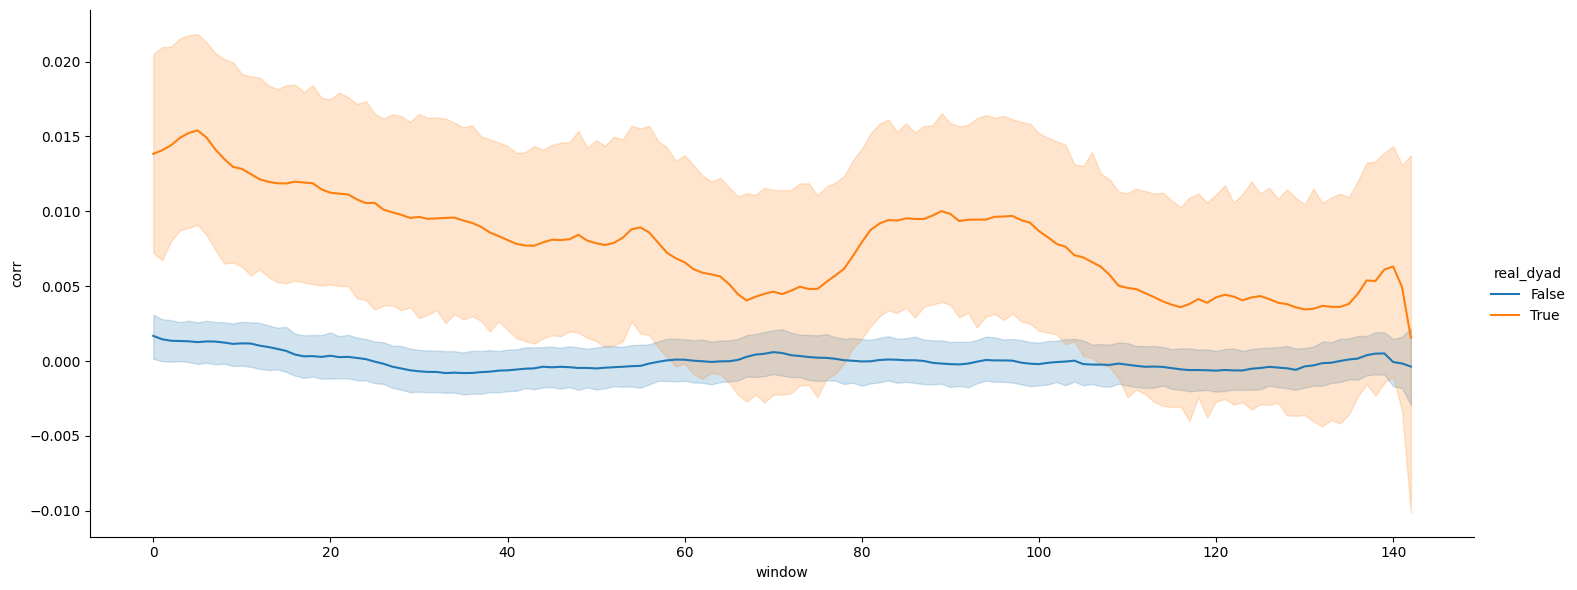

In [74]:
# Where in time is the effect?
df_analysis = df_lags
#df_analysis = df_analysis.with_columns(pl.col("corr").abs().alias("corr"))
df_analysis = df_analysis.filter(pl.col(["lag"]) > -10)
df_analysis = df_analysis.filter(pl.col(["lag"]) < 0)
df_analysis = df_analysis.group_by(["sid", "dyad", "user_id", "real_dyad", "window"]).mean().to_pandas()

sns.relplot(x="window", y="corr",hue="real_dyad", data=df_analysis, aspect=2.5, height=6, kind="line")

### Compare with conditions

#### Format data

In [6]:
behavior_df = pl.read_csv("data/behavior/all_data_df.csv")

behavior_df = behavior_df.with_columns(
    pl.col("sid").str.replace_all(":", "").alias("sid"),
    pl.col("user_id").str.replace_all(":", "").alias("user_id"),
    pl.col("other_id").str.replace_all(":", "").alias("other_id")
)

In [7]:
df_analysis = df_lags.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "lag"]).mean()
merge_df = behavior_df.join(df_analysis, on=["user_id", "sid", "dyad", "other_id"])
merge_df = merge_df.with_columns(
    (pl.col("participant_condition") + pl.col("other_condition")).alias("u_cond")
)


In [8]:
merge_df = merge_df.write_csv("data/merge_df.csv")

#### Analysis

In [75]:
merge_df = pl.read_csv("data/merge_df.csv")

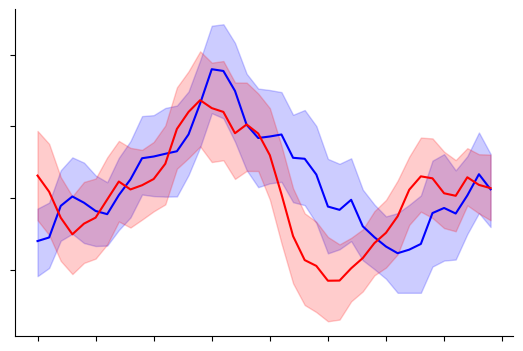

In [10]:
df_analysis = merge_df.filter(pl.col("u_cond") != "SU")
df_analysis = df_analysis.filter(pl.col("u_cond") != "US")
df_analysis = df_analysis.filter(pl.col("real_dyad") == True).to_pandas()

g = sns.relplot( x="lag",y="corr", hue="u_cond",kind="line", data=df_analysis
            , aspect=1.5, height=4, hue_order=["UU", "SS"], palette= sns.color_palette(["blue", "red"])
            , errorbar=('ci', 95)
            , legend = False
        
            )


plt.savefig("plots/hr_lags_condition_legend.pdf", bbox_inches='tight')
g.set(xticklabels=[], yticklabels=[], title='',xlabel=None, ylabel=None)
plt.savefig("plots/hr_lags_condition.pdf", bbox_inches='tight')



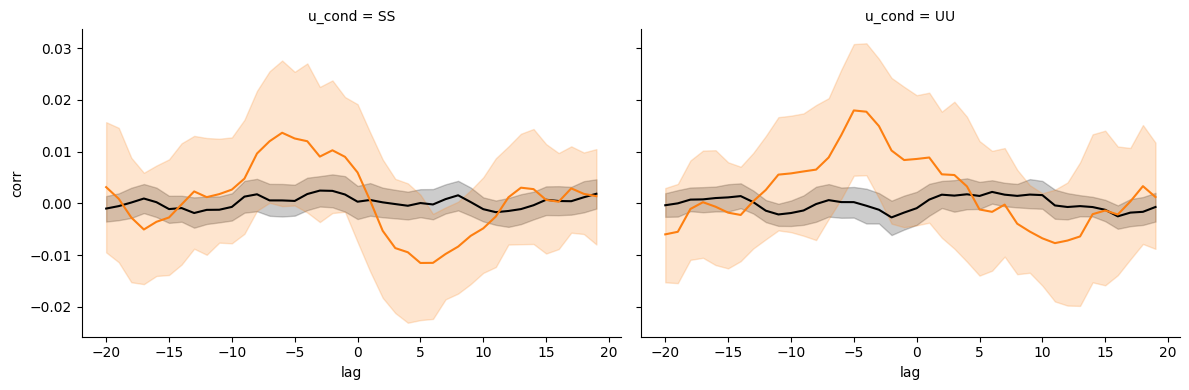

In [21]:
df_analysis = merge_df.filter(pl.col("u_cond") != "SU")

df_analysis = df_analysis.filter(pl.col("u_cond") != "US")

df_analysis = df_analysis.group_by(["sid", "user_id", "u_cond", "real_dyad", "lag"]).mean().to_pandas()

g = sns.relplot( x="lag",y="corr", col="u_cond",hue="real_dyad", kind="line", data=df_analysis
            , aspect=1.5, height=4
            , errorbar=('ci', 95)
            , legend = False
            , palette = ["#000000", "#FD7F11"]
            )

plt.savefig("plots/hr_lags_condition_with_surrogate_legend.pdf", bbox_inches='tight')
#g.set(xticklabels=[], yticklabels=[], title='',xlabel=None, ylabel=None)
#plt.savefig("plots/hr_lags_condition_with_surrogate.pdf", bbox_inches='tight')



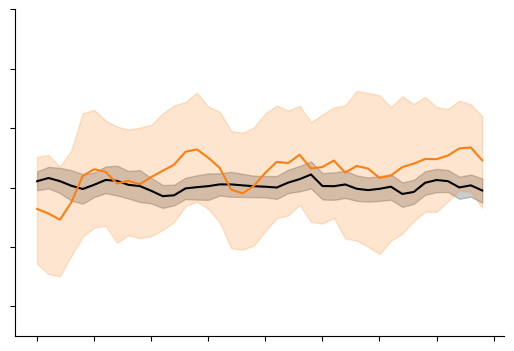

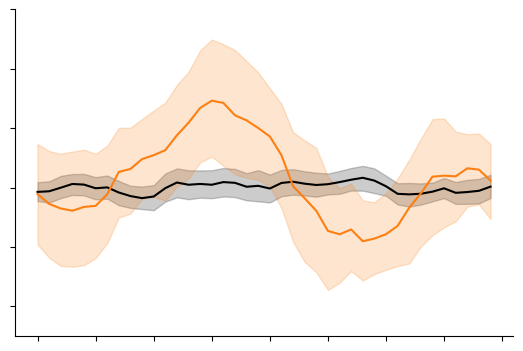

In [77]:
conditions = {"incongruent" : ["SU", "US"], "congruent" : ["SS", "UU"]} 

for condition in conditions:
    df_analysis = merge_df
    df_analysis = df_analysis.filter(pl.col("u_cond").is_in(conditions[condition]))
    
    df_analysis = df_analysis.group_by(["sid", "user_id", "real_dyad", "lag"]).mean().to_pandas()
    
    
    g = sns.relplot( x="lag",y="corr",hue="real_dyad", kind="line", data=df_analysis
                , aspect=1.5, height=4
                , errorbar=('ci', 95)
                , legend = False
                , palette = ["#000000", "#FD7F11"]
                )

    g.set(ylim=(-0.025, 0.03))    
    plt.savefig("plots/"+condition+"_hr_lags_condition_with_surrogate_legend.pdf", bbox_inches='tight')
    g.set(xticklabels=[], yticklabels=[], title='',xlabel=None, ylabel=None)
    plt.savefig("plots/"+condition+"hr_lags_condition_with_surrogate.pdf", bbox_inches='tight')
    


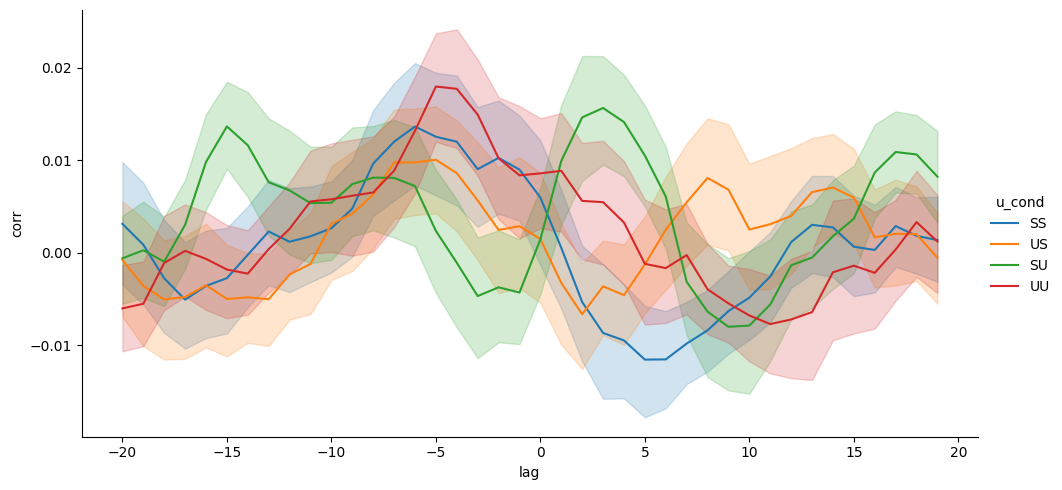

In [13]:
df_analysis = merge_df
#df_analysis = df_analysis.filter(pl.col("u_cond") != "SU")
#df_analysis = df_analysis.filter(pl.col("u_cond") != "US")
df_analysis = df_analysis.filter(pl.col("real_dyad") == True).to_pandas()

sns.relplot( x="lag",y="corr", hue="u_cond",kind="line", data=df_analysis, aspect=2)

-----------------------------------------
Analysing CONDITION: ['SS', 'UU']
Shape of data_true: (53, 40)
Shape of data_false: (54, 40)
stat_fun(H1): min=0.00011543441574040097 max=8.950412013608904
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Raw clusters:
Cluster 1: (array([ 9, 10]),)
Cluster 2: (array([12, 13, 14, 15, 16, 17, 18, 19, 20]),)
Cluster 3: (array([26, 27, 28, 29, 30]),)
Significant clusters (p <= 0.05):
Cluster 2:
Indices: [12 13 14 15 16 17 18 19 20]
Lag range: -8 to 0
p-value: 0.0273


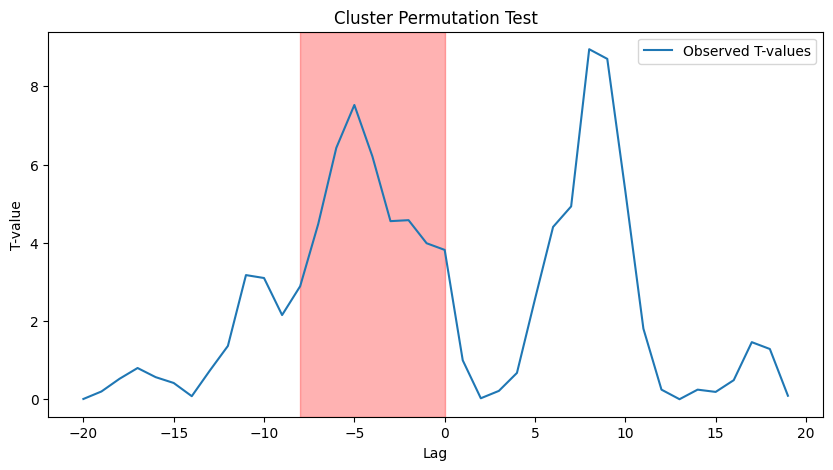

In [14]:
# Group and aggregate the data
df_analysis = merge_df

#condition = ["SU", "US"]
condition = ["SS", "UU"]

df_analysis = df_analysis.filter(pl.col("u_cond").is_in(condition))

df_analysis = df_analysis.group_by(["sid", "user_id", "real_dyad", "lag"]).mean().to_pandas()

# Pivot the data to have separate columns for True and False real_dyad
df_pivot = df_analysis.pivot_table(index=["sid", "user_id", "lag"], 
                                   columns="real_dyad", values="corr").reset_index()

# Rename the columns for clarity
df_pivot.columns = ['sid', 'user_id', 'lag', 'False', 'True']

# Prepare the data for mne
times = df_pivot['lag'].unique()

data_true = df_pivot[df_pivot['True'].notna()]['True'].values.reshape(-1, len(times))
data_false = df_pivot[df_pivot['False'].notna()]['False'].values.reshape(-1, len(times))

# Print shapes of the data arrays for debugging
print("-----------------------------------------")
print("Analysing CONDITION:", condition)
print("Shape of data_true:", data_true.shape)
print("Shape of data_false:", data_false.shape)

# Print data samples for initial lags
#print("Data at initial lags for True condition:", data_true[:, 0])
#print("Data at initial lags for False condition:", data_false[:, 0])

# Ensure the data is correctly reshaped
assert data_true.shape[1] == len(times), "Reshaping error for True data"
assert data_false.shape[1] == len(times), "Reshaping error for False data"

# Combine the data for the test
data = [data_true, data_false]

# Perform the cluster permutation test
T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
    data, n_permutations=10000, threshold=2.842517, tail=1, n_jobs=1)

# Print the raw clusters
print("Raw clusters:")
for i, cluster in enumerate(clusters):
    print(f"Cluster {i+1}: {cluster}")

# Print the significant clusters with indices
print("Significant clusters (p <= 0.05):")
for i_c, c in enumerate(clusters):
    if cluster_p_values[i_c] <= 0.05:
        c_indices = c[0]  # Extract indices of the cluster
        print(f"Cluster {i_c + 1}:")
        print(f"Indices: {c_indices}")
        print(f"Lag range: {times[c_indices[0]]} to {times[c_indices[-1]]}")
        print(f"p-value: {cluster_p_values[i_c]}")

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(times, T_obs, label='Observed T-values')
plt.xlabel('Lag')
plt.ylabel('T-value')
plt.title('Cluster Permutation Test')

# Highlight significant clusters
for i_c, c in enumerate(clusters):
    if cluster_p_values[i_c] <= 0.05:
        c_indices = c[0]  # Extract indices of the cluster
        plt.axvspan(times[c_indices[0]], times[c_indices[-1]], color='r', alpha=0.3)

plt.legend()
plt.show()


#### Compare Time

#### Format data

In [22]:
behavior_df = pl.read_csv("data/behavior/all_data_df.csv")

behavior_df = behavior_df.with_columns(
    pl.col("sid").str.replace_all(":", "").alias("sid"),
    pl.col("user_id").str.replace_all(":", "").alias("user_id"),
    pl.col("other_id").str.replace_all(":", "").alias("other_id")
)

In [23]:
df_analysis = df_lags

df_analysis = df_analysis.filter(pl.col(["lag"]) > -10)
df_analysis = df_analysis.filter(pl.col(["lag"]) < 0)

df_analysis = df_analysis.group_by(["sid", "dyad", "user_id", "other_id", "real_dyad", "window"]).mean()
time_df = behavior_df.join(df_analysis, on=["user_id", "sid", "dyad", "other_id"])
time_df = time_df.with_columns(
    (pl.col("participant_condition") + pl.col("other_condition")).alias("u_cond")
)


In [24]:
time_df = time_df.write_csv("data/time_df.csv")

#### Analysis

In [36]:
time_df = pl.read_csv("data/time_df.csv")

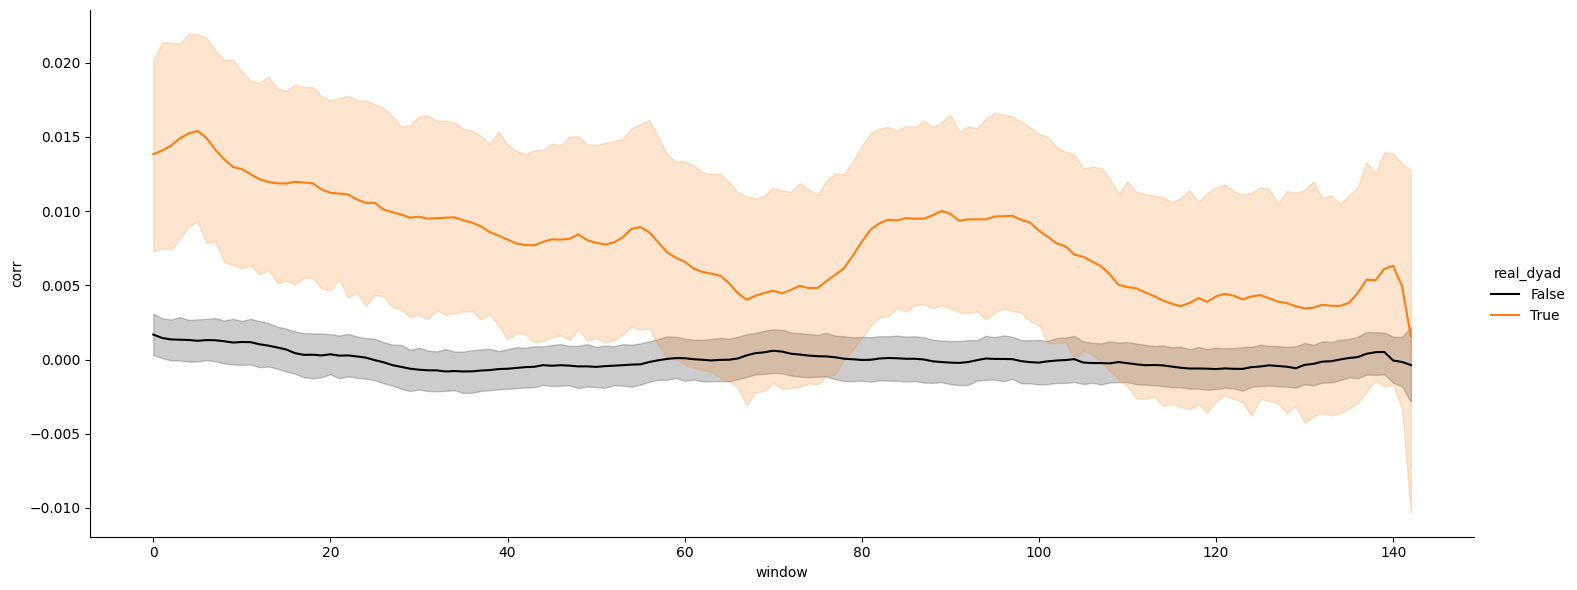

In [4]:
# Where in time is the effect?
df_analysis = time_df
df_analysis = df_analysis.group_by(["sid", "dyad", "user_id", "real_dyad", "window"]).mean().to_pandas()

sns.relplot(x="window", y="corr",hue="real_dyad", data=df_analysis, aspect=2.5
            , height=6, kind="line"
            , palette = ["#000000", "#FD7F11"]
           )

In [ ]:
# Where in time is the effect?
conditions = {"incongruent" : ["SU", "US"], "congruent" : ["SS", "UU"], "all"  : ["SS", "UU", "SU", "US"]} 

for condition in conditions.keys():
    df_analysis = time_df
    df_analysis = df_analysis.filter(pl.col("u_cond").is_in(conditions[condition]))
    df_analysis = df_analysis.group_by(["sid", "dyad", "user_id", "real_dyad", "window"]).mean().to_pandas()
    g = sns.relplot(x="window", y="corr",hue="real_dyad", data=df_analysis, aspect=1.3
                , height=3, kind="line"
                , palette = ["#000000", "#FD7F11"]
                , legend=False
               )

    g.set(ylim=(-0.025, 0.035))    
    plt.savefig("plots/"+condition+"time_with_surrogate_legend.pdf", bbox_inches='tight')
    g.set(xticklabels=[], yticklabels=[], title='',xlabel=None, ylabel=None)
    plt.savefig("plots/"+condition+"time_with_surrogate.pdf", bbox_inches='tight')

-----------------------------------------
Analysing CONDITION: ['SS', 'UU']
Shape of data_true: (54, 143)
Shape of data_false: (54, 143)
stat_fun(H1): min=0.5492189172996214 max=26.413091132743826
Running initial clustering …
Found 7 clusters


/tmp/ipykernel_30572/1081655355.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_pivot


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Raw clusters:
Cluster 1: (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62]),)
Cluster 2: (array([82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92]),)
Cluster 3: (array([94, 95, 96, 97, 98]),)
Cluster 4: (array([102]),)
Cluster 5: (array([104, 105, 106, 107]),)
Cluster 6: (array([117]),)
Cluster 7: (array([138, 139, 140]),)
Significant clusters (p <= 0.05):
Cluster 1:
Indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62]
Lag range: 1 to 63
p-value: 0.0025


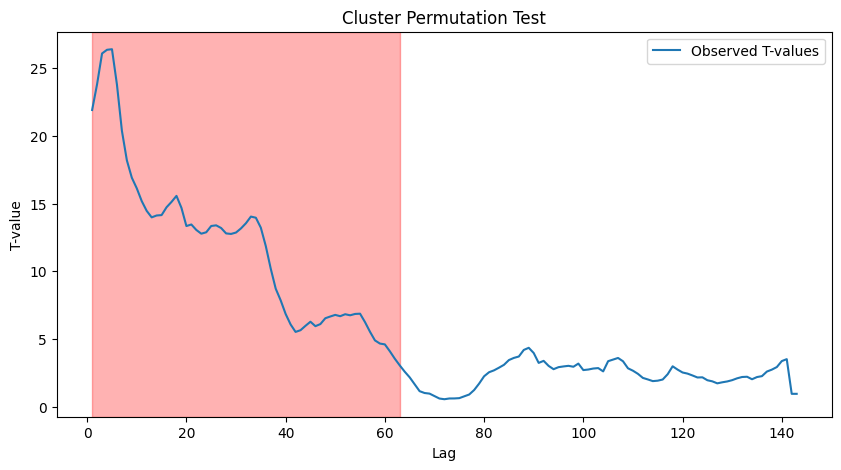

In [66]:
# Group and aggregate the data
df_analysis = time_df

#condition = ["SU", "US"]
#condition = ["SS", "UU"]
condition = ["SS", "UU", "SU", "US"]

df_analysis = df_analysis.filter(pl.col("u_cond").is_in(condition))

df_analysis = df_analysis.group_by(["sid", "user_id", "real_dyad", "window"]).mean().to_pandas()

# Pivot the data to have separate columns for True and False real_dyad
df_pivot = df_analysis.pivot_table(index=["sid", "user_id", "window"], 
                                   columns="real_dyad", values="corr").reset_index()
# Rename the columns for clarity
df_pivot.columns = ['sid', 'user_id', 'window', 'False', 'True']

#Deal with missing values
# Define the full range for reindexing (e.g., from 1 to 143)
full_range = pd.Index(range(1, 144))  # Adjust the range as necessary

# Reindex each group, fill missing values with NaN, then forward fill within each group
df_pivot = (
    df_pivot
    .groupby(["user_id"], as_index=False, group_keys=False)
    .apply(lambda group: group.set_index("window").reindex(full_range).rename_axis("window").ffill().reset_index())
)

# Prepare the data for mne
times = df_pivot['window'].unique()

df_pivot["True"] = df_pivot["True"].bfill()
df_pivot["True"] = df_pivot["True"].ffill()
df_pivot["False"] = df_pivot["False"].bfill()
df_pivot["False"] = df_pivot["False"].ffill()

data_true = df_pivot[df_pivot['True'].notna()]['True'].values.reshape(-1, len(times))
data_false = df_pivot[df_pivot['False'].notna()]['False'].values.reshape(-1, len(times))

# Print shapes of the data arrays for debugging
print("-----------------------------------------")
print("Analysing CONDITION:", condition)
print("Shape of data_true:", data_true.shape)
print("Shape of data_false:", data_false.shape)

# Print data samples for initial lags
#print("Data at initial lags for True condition:", data_true[:, 0])
#print("Data at initial lags for False condition:", data_false[:, 0])

# Ensure the data is correctly reshaped
assert data_true.shape[1] == len(times), "Reshaping error for True data"
assert data_false.shape[1] == len(times), "Reshaping error for False data"

# Combine the data for the test
data = [data_true, data_false]

# Perform the cluster permutation test
T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
    data, n_permutations=10000, threshold=2.842517, tail=1, n_jobs=1)

# Print the raw clusters
print("Raw clusters:")
for i, cluster in enumerate(clusters):
    print(f"Cluster {i+1}: {cluster}")

# Print the significant clusters with indices
print("Significant clusters (p <= 0.05):")
for i_c, c in enumerate(clusters):
    if cluster_p_values[i_c] <= 0.05:
        c_indices = c[0]  # Extract indices of the cluster
        print(f"Cluster {i_c + 1}:")
        print(f"Indices: {c_indices}")
        print(f"Lag range: {times[c_indices[0]]} to {times[c_indices[-1]]}")
        print(f"p-value: {cluster_p_values[i_c]}")

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(times, T_obs, label='Observed T-values')
plt.xlabel('Lag')
plt.ylabel('T-value')
plt.title('Cluster Permutation Test')

# Highlight significant clusters
for i_c, c in enumerate(clusters):
    if cluster_p_values[i_c] <= 0.05:
        c_indices = c[0]  # Extract indices of the cluster
        plt.axvspan(times[c_indices[0]], times[c_indices[-1]], color='r', alpha=0.3)

plt.legend()
plt.show()
